In [ ]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

## infoGAN

### Dataset 준비

In [ ]:
%%capture
!pip install torchinfo torchmetrics

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython import display
plt.rcParams['figure.figsize'] = [5, 3.5]

device = 'cuda:0'
torch.__version__

'2.6.0+cu124'

In [ ]:
import torchvision.transforms as v2
from torchvision.datasets import FashionMNIST, MNIST

class Normalize(object):
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        return torch.FloatTensor(image).unsqueeze(dim=0)

class Onehot(object):
    def __call__(self, sample):
        sample = sample
        target = np.eye(10)[sample]
        return torch.FloatTensor(target)

# Normalize data to [-1 ~ 1]
mnist_transform = v2.Compose([Normalize(),])
target_transform = v2.Compose([Onehot(),])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True, target_transform=target_transform)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                     download=True, target_transform=target_transform)

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


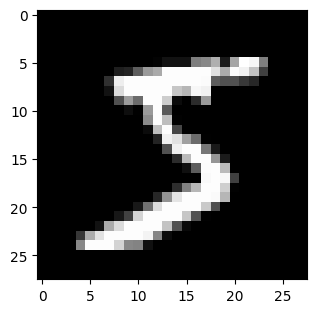

In [ ]:
plt.imshow(train_dataset[0][0][0, :, :], cmap='gray')
print(train_dataset[0][1])

- model params

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 600
EPOCHS = 100
latent_code_dim=10  ## latent code
noise_dim = 90      ## z-vector
IN_PUT_DIM=latent_code_dim+noise_dim
num_examples_to_generate = 16
IMG_SHAPE=(1,28,28)

In [ ]:
train_dataloader = DataLoader(train_dataset, BATCH_SIZE, True, num_workers=4)
test_dataloader = DataLoader(test_dataset, BATCH_SIZE, False, num_workers=4)

### Model define

In [ ]:
# InfoGenerator model
class InfoGenerator(nn.Module):
    def __init__(self, input_dim):
        super(InfoGenerator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(input_dim, 256*7*7, bias=False),
            nn.Unflatten(1, (256, 7, 7)),    #(?,12544)
            nn.BatchNorm2d(256,momentum=0.8),#(256,7,7)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 5, 1, padding=2, bias=False),
            nn.BatchNorm2d(128,momentum=0.8),#(128,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 5, 2,
                               padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(64,momentum=0.8),#(64,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 1, 5, 2,
                               padding=2, output_padding=1, bias=False),
            nn.Tanh() )                     #(1,28,28)
    def forward(self, noise, label, code1, code2):
        noise = noise.to(device)
        label = label.to(device)
        code1 = code1.to(device)
        code2 = code2.to(device)
        inputs = torch.cat([noise, label, code1, code2], dim=1)
        out = self.generator(inputs)
        return out
info_generator = InfoGenerator(noise_dim+latent_code_dim+1+1)
summary(info_generator, input_size=[(BATCH_SIZE, noise_dim),
                                    (BATCH_SIZE, latent_code_dim),
                                    (BATCH_SIZE, 1), (BATCH_SIZE, 1)])

Layer (type:depth-idx)                   Output Shape              Param #
InfoGenerator                            [600, 1, 28, 28]          --
├─Sequential: 1-1                        [600, 1, 28, 28]          --
│    └─Linear: 2-1                       [600, 12544]              1,279,488
│    └─Unflatten: 2-2                    [600, 256, 7, 7]          --
│    └─BatchNorm2d: 2-3                  [600, 256, 7, 7]          512
│    └─LeakyReLU: 2-4                    [600, 256, 7, 7]          --
│    └─ConvTranspose2d: 2-5              [600, 128, 7, 7]          819,200
│    └─BatchNorm2d: 2-6                  [600, 128, 7, 7]          256
│    └─LeakyReLU: 2-7                    [600, 128, 7, 7]          --
│    └─ConvTranspose2d: 2-8              [600, 64, 14, 14]         204,800
│    └─BatchNorm2d: 2-9                  [600, 64, 14, 14]         128
│    └─LeakyReLU: 2-10                   [600, 64, 14, 14]         --
│    └─ConvTranspose2d: 2-11             [600, 1, 28, 28]        

In [ ]:
# InfoDiscriminator model
class InfoDiscriminator(nn.Module):
    def __init__(self, label_dim):
        super(InfoDiscriminator, self).__init__()
        self.discriminator = nn.Sequential(
            nn.Conv2d(1, 64, 5, 2, padding=2),  #(64,14,14)
            nn.LeakyReLU(0.2), #nn.Dropout(0.25),
            nn.Conv2d(64, 128, 5, 2, padding=2),#(128,7,7)
            nn.LeakyReLU(0.2), #nn.Dropout(0.25),
            nn.Flatten() )
        self.discLinear = nn.Sequential(
            nn.Linear(128*7*7, 1),              #(?,1)
            nn.Sigmoid() )                      #(real/fack)
        self.firstLinear = nn.Linear(128*7*7, 128)
        self.acLinear = nn.Linear(128, label_dim)#(labels)
        self.code1Linear = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid() )                      #(code1)
        self.code2Linear = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid() )                      #(code2)
    def forward(self, x):
        out = self.discriminator(x)
        disc_out = self.discLinear(out)         #(real/fack)
        out2 = self.firstLinear(out)            #(?,128)
        label_out = self.acLinear(out2)         #(labels)
        code1 = self.code1Linear(out2)          #(code1)
        code2 = self.code2Linear(out2)          #(code2)
        return disc_out, label_out, code1, code2
info_discriminator = InfoDiscriminator(latent_code_dim).to(device)
summary(info_discriminator, input_size=[(BATCH_SIZE, 1, 28, 28)])

Layer (type:depth-idx)                   Output Shape              Param #
InfoDiscriminator                        [600, 1]                  --
├─Sequential: 1-1                        [600, 6272]               --
│    └─Conv2d: 2-1                       [600, 64, 14, 14]         1,664
│    └─LeakyReLU: 2-2                    [600, 64, 14, 14]         --
│    └─Conv2d: 2-3                       [600, 128, 7, 7]          204,928
│    └─LeakyReLU: 2-4                    [600, 128, 7, 7]          --
│    └─Flatten: 2-5                      [600, 6272]               --
├─Sequential: 1-2                        [600, 1]                  --
│    └─Linear: 2-6                       [600, 1]                  6,273
│    └─Sigmoid: 2-7                      [600, 1]                  --
├─Linear: 1-3                            [600, 128]                802,944
├─Linear: 1-4                            [600, 10]                 1,290
├─Sequential: 1-5                        [600, 1]                 

### Model 생성 및 학습조건 설정

In [ ]:
### mutual information 계산
# noise z와 code c를 가지고 생성한 이미지 x
# 이미지 x로 부터 구한 코드 c'
# c분포와 c'분포의 cross entropy 계산
# mi_loss = - c * log(Q(c|x))
def mi_loss(q_of_c_given_x, c):
    r = -torch.mean(torch.sum(
          c * torch.log( q_of_c_given_x + 1e-7), dim=1 ))
    return r

In [ ]:
import torchmetrics as FM

lr = 2e-4
decay = 6e-8
#bce_loss = nn.MSELoss() #LS-GAN
bce_loss = nn.BCELoss()
cce_loss = nn.CrossEntropyLoss()
m_acc = FM.Accuracy(task="multiclass", num_classes=10).to(device)
b_acc = FM.Accuracy(task="binary").to(device)

mi_loss = mi_loss
info_generator = info_generator.to(device)
info_discriminator = info_discriminator.to(device)
optimizer_generator = torch.optim.RMSprop(info_generator.parameters(), lr=lr*0.5,weight_decay=decay*0.5)
optimizer_discriminator = torch.optim.RMSprop(info_discriminator.parameters(), lr=lr,weight_decay=decay)

In [ ]:
def generate_and_save_images(model, epoch):
    r, c = 10, 10
    fig, axs = plt.subplots(r, c)
    for i in range(c):
        noise_input = torch.Tensor(np.random.uniform(-1.0,1.0,size=[r, noise_dim])).to(device)
        noise_label = torch.Tensor(np.eye(r, 10)[np.full(fill_value=i, shape=(r))]).to(device)
        code_std = 2
        a = torch.linspace(-code_std, code_std, 10).view(-1, 1).to(device)
        noise_code1 = torch.ones((10, 1)).to(device) * a
        a = torch.linspace(-code_std, code_std, 10).view(-1, 1).to(device)
        noise_code2 = torch.ones((10, 1)).to(device) * a

        gen_imgs = model(noise_input, noise_label, noise_code1, noise_code2)###
        gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
        for j in range(r):
            axs[j,i].imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap='gray')
            axs[j,i].axis('off')
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

### Training

Epoch: 0 Loss D:-0.506, Loss G:-2.400, RealAcc:0.875, FakeAcc:0.997
Epoch: 1 Loss D:-0.815, Loss G:-2.440, RealAcc:0.903, FakeAcc:1.000
Epoch: 2 Loss D:-0.805, Loss G:-2.411, RealAcc:0.928, FakeAcc:1.000
Epoch: 3 Loss D:-0.813, Loss G:-2.520, RealAcc:0.962, FakeAcc:1.000
Epoch: 4 Loss D:-1.019, Loss G:-2.591, RealAcc:0.940, FakeAcc:1.000
Epoch: 5 Loss D:-0.943, Loss G:-2.603, RealAcc:0.970, FakeAcc:1.000
Epoch: 6 Loss D:-0.897, Loss G:-2.627, RealAcc:0.948, FakeAcc:0.997
Epoch: 7 Loss D:-0.997, Loss G:-2.550, RealAcc:0.957, FakeAcc:1.000
Epoch: 8 Loss D:-0.930, Loss G:-2.668, RealAcc:0.972, FakeAcc:1.000


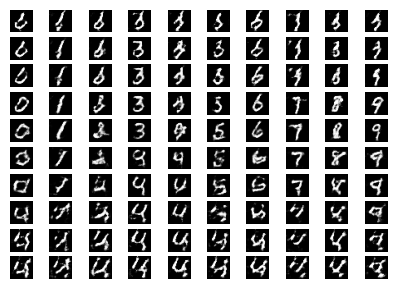

Epoch: 10 Loss D:-0.940, Loss G:-2.694, RealAcc:0.980, FakeAcc:0.997
Epoch: 11 Loss D:-0.941, Loss G:-2.629, RealAcc:0.977, FakeAcc:0.998
Epoch: 12 Loss D:-1.009, Loss G:-2.537, RealAcc:0.982, FakeAcc:0.997
Epoch: 13 Loss D:-0.994, Loss G:-2.392, RealAcc:0.973, FakeAcc:0.998
Epoch: 14 Loss D:-0.984, Loss G:-2.697, RealAcc:0.980, FakeAcc:0.998
Epoch: 15 Loss D:-0.900, Loss G:-2.597, RealAcc:0.975, FakeAcc:1.000
Epoch: 16 Loss D:-0.876, Loss G:-2.784, RealAcc:0.988, FakeAcc:0.998
Epoch: 17 Loss D:-0.966, Loss G:-2.433, RealAcc:0.975, FakeAcc:0.997
Epoch: 18 Loss D:-0.945, Loss G:-2.458, RealAcc:0.977, FakeAcc:0.997


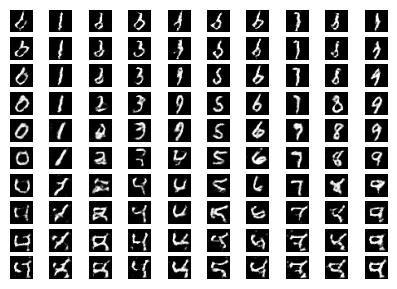

Epoch: 20 Loss D:-0.944, Loss G:-2.537, RealAcc:0.980, FakeAcc:1.000
Epoch: 21 Loss D:-0.986, Loss G:-2.631, RealAcc:0.988, FakeAcc:1.000
Epoch: 22 Loss D:-0.917, Loss G:-2.462, RealAcc:0.983, FakeAcc:0.997
Epoch: 23 Loss D:-0.981, Loss G:-2.651, RealAcc:0.988, FakeAcc:0.997
Epoch: 24 Loss D:-0.893, Loss G:-2.479, RealAcc:0.990, FakeAcc:0.998
Epoch: 25 Loss D:-0.880, Loss G:-2.566, RealAcc:0.990, FakeAcc:0.998
Epoch: 26 Loss D:-0.970, Loss G:-2.614, RealAcc:0.993, FakeAcc:0.997
Epoch: 27 Loss D:-1.040, Loss G:-2.382, RealAcc:0.990, FakeAcc:1.000
Epoch: 28 Loss D:-0.924, Loss G:-2.418, RealAcc:0.995, FakeAcc:0.998


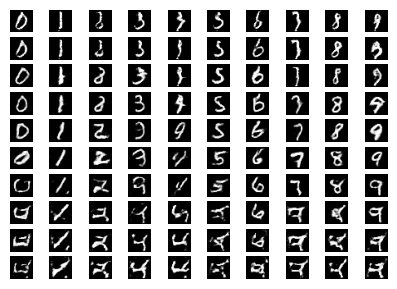

Epoch: 30 Loss D:-0.859, Loss G:-2.697, RealAcc:0.992, FakeAcc:0.997
Epoch: 31 Loss D:-1.000, Loss G:-2.492, RealAcc:0.995, FakeAcc:0.998
Epoch: 32 Loss D:-0.873, Loss G:-2.886, RealAcc:0.988, FakeAcc:1.000
Epoch: 33 Loss D:-0.976, Loss G:-2.466, RealAcc:0.997, FakeAcc:1.000
Epoch: 34 Loss D:-1.030, Loss G:-2.712, RealAcc:0.997, FakeAcc:1.000
Epoch: 35 Loss D:-0.900, Loss G:-2.483, RealAcc:0.997, FakeAcc:1.000
Epoch: 36 Loss D:-1.052, Loss G:-2.524, RealAcc:0.995, FakeAcc:1.000
Epoch: 37 Loss D:-0.819, Loss G:-2.711, RealAcc:0.993, FakeAcc:1.000
Epoch: 38 Loss D:-0.926, Loss G:-2.566, RealAcc:0.998, FakeAcc:1.000


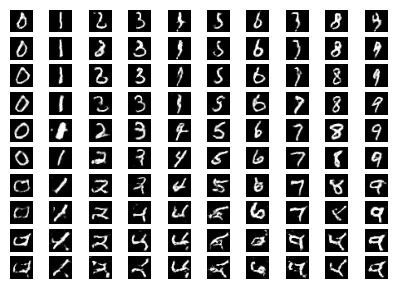

Epoch: 40 Loss D:-1.098, Loss G:-2.580, RealAcc:0.995, FakeAcc:0.998
Epoch: 41 Loss D:-0.958, Loss G:-2.475, RealAcc:0.998, FakeAcc:0.998
Epoch: 42 Loss D:-1.018, Loss G:-2.599, RealAcc:0.997, FakeAcc:1.000
Epoch: 43 Loss D:-1.042, Loss G:-2.475, RealAcc:0.997, FakeAcc:1.000
Epoch: 44 Loss D:-0.818, Loss G:-2.555, RealAcc:0.995, FakeAcc:0.998
Epoch: 45 Loss D:-0.890, Loss G:-2.688, RealAcc:0.998, FakeAcc:1.000
Epoch: 46 Loss D:-0.917, Loss G:-2.655, RealAcc:0.997, FakeAcc:0.997
Epoch: 47 Loss D:-0.954, Loss G:-2.513, RealAcc:0.997, FakeAcc:1.000
Epoch: 48 Loss D:-1.005, Loss G:-2.519, RealAcc:0.998, FakeAcc:0.998


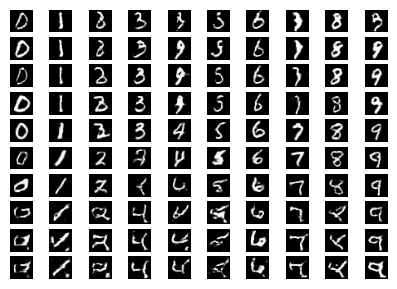

Epoch: 50 Loss D:-1.041, Loss G:-2.446, RealAcc:1.000, FakeAcc:1.000
Epoch: 51 Loss D:-0.951, Loss G:-2.840, RealAcc:0.997, FakeAcc:1.000
Epoch: 52 Loss D:-0.836, Loss G:-2.372, RealAcc:0.997, FakeAcc:1.000
Epoch: 53 Loss D:-0.843, Loss G:-2.574, RealAcc:0.997, FakeAcc:1.000
Epoch: 54 Loss D:-0.961, Loss G:-2.523, RealAcc:0.998, FakeAcc:0.998
Epoch: 55 Loss D:-0.998, Loss G:-2.738, RealAcc:0.995, FakeAcc:1.000
Epoch: 56 Loss D:-0.957, Loss G:-2.606, RealAcc:1.000, FakeAcc:0.998
Epoch: 57 Loss D:-0.913, Loss G:-2.422, RealAcc:0.993, FakeAcc:1.000
Epoch: 58 Loss D:-1.092, Loss G:-2.604, RealAcc:1.000, FakeAcc:1.000


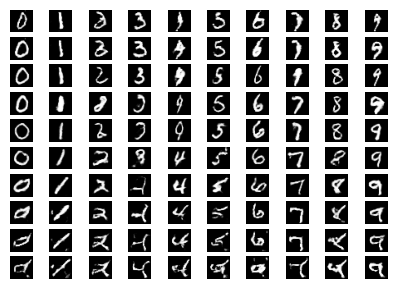

Epoch: 60 Loss D:-0.961, Loss G:-2.216, RealAcc:0.995, FakeAcc:1.000
Epoch: 61 Loss D:-0.920, Loss G:-2.623, RealAcc:0.998, FakeAcc:1.000
Epoch: 62 Loss D:-1.029, Loss G:-2.743, RealAcc:1.000, FakeAcc:1.000
Epoch: 63 Loss D:-0.998, Loss G:-2.559, RealAcc:1.000, FakeAcc:0.998
Epoch: 64 Loss D:-0.960, Loss G:-2.564, RealAcc:1.000, FakeAcc:1.000
Epoch: 65 Loss D:-1.041, Loss G:-2.368, RealAcc:1.000, FakeAcc:1.000
Epoch: 66 Loss D:-1.016, Loss G:-2.452, RealAcc:1.000, FakeAcc:1.000
Epoch: 67 Loss D:-0.914, Loss G:-2.817, RealAcc:1.000, FakeAcc:1.000
Epoch: 68 Loss D:-0.930, Loss G:-2.746, RealAcc:0.997, FakeAcc:1.000


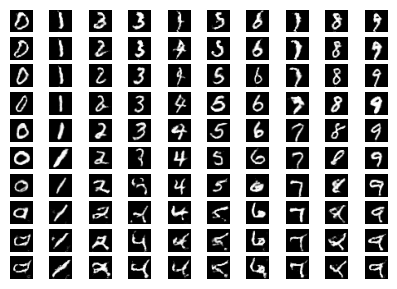

Epoch: 70 Loss D:-0.986, Loss G:-2.492, RealAcc:1.000, FakeAcc:0.998
Epoch: 71 Loss D:-0.879, Loss G:-2.418, RealAcc:0.998, FakeAcc:1.000
Epoch: 72 Loss D:-0.942, Loss G:-2.533, RealAcc:0.998, FakeAcc:0.998
Epoch: 73 Loss D:-0.862, Loss G:-2.615, RealAcc:0.997, FakeAcc:0.998
Epoch: 74 Loss D:-1.036, Loss G:-2.639, RealAcc:1.000, FakeAcc:1.000
Epoch: 75 Loss D:-0.929, Loss G:-2.886, RealAcc:1.000, FakeAcc:0.998
Epoch: 76 Loss D:-1.100, Loss G:-2.557, RealAcc:0.998, FakeAcc:1.000
Epoch: 77 Loss D:-0.832, Loss G:-2.564, RealAcc:0.997, FakeAcc:1.000
Epoch: 78 Loss D:-1.042, Loss G:-2.613, RealAcc:1.000, FakeAcc:1.000


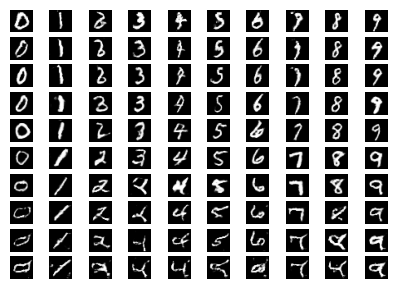

Epoch: 80 Loss D:-1.063, Loss G:-2.606, RealAcc:0.997, FakeAcc:1.000
Epoch: 81 Loss D:-1.048, Loss G:-2.718, RealAcc:1.000, FakeAcc:1.000
Epoch: 82 Loss D:-0.936, Loss G:-2.661, RealAcc:0.997, FakeAcc:0.995
Epoch: 83 Loss D:-0.865, Loss G:-2.413, RealAcc:1.000, FakeAcc:1.000
Epoch: 84 Loss D:-0.896, Loss G:-2.501, RealAcc:1.000, FakeAcc:1.000
Epoch: 85 Loss D:-0.881, Loss G:-2.591, RealAcc:1.000, FakeAcc:0.997
Epoch: 86 Loss D:-0.946, Loss G:-2.566, RealAcc:1.000, FakeAcc:0.998
Epoch: 87 Loss D:-0.973, Loss G:-2.450, RealAcc:1.000, FakeAcc:1.000
Epoch: 88 Loss D:-0.908, Loss G:-2.487, RealAcc:0.997, FakeAcc:1.000


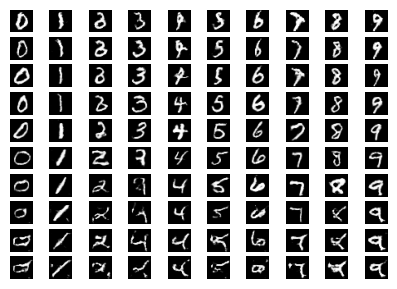

Epoch: 90 Loss D:-0.988, Loss G:-2.616, RealAcc:1.000, FakeAcc:1.000
Epoch: 91 Loss D:-0.948, Loss G:-2.755, RealAcc:1.000, FakeAcc:1.000
Epoch: 92 Loss D:-1.016, Loss G:-2.540, RealAcc:1.000, FakeAcc:1.000
Epoch: 93 Loss D:-0.959, Loss G:-2.454, RealAcc:1.000, FakeAcc:1.000
Epoch: 94 Loss D:-1.103, Loss G:-2.441, RealAcc:0.998, FakeAcc:1.000
Epoch: 95 Loss D:-0.882, Loss G:-2.572, RealAcc:1.000, FakeAcc:1.000
Epoch: 96 Loss D:-0.895, Loss G:-2.741, RealAcc:1.000, FakeAcc:1.000
Epoch: 97 Loss D:-0.863, Loss G:-2.544, RealAcc:1.000, FakeAcc:1.000
Epoch: 98 Loss D:-0.910, Loss G:-2.733, RealAcc:1.000, FakeAcc:0.998


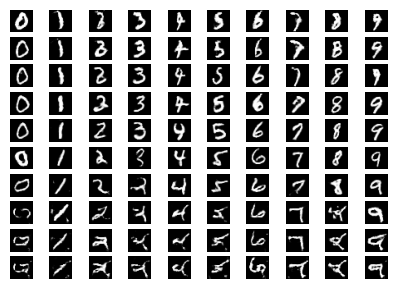

CPU times: user 15min 38s, sys: 28.2 s, total: 16min 6s
Wall time: 7min 16s


In [ ]:
%%time
loss_real_disc_s=[]
loss_real_mi_s=[]
loss_fake_disc_s=[]
loss_fake_mi_s=[]
loss_gen_ce_s=[]
loss_gen_mi_s=[]
acc_disc_real_s=[]
acc_disc_fake_s=[]
acc_class_real_s=[]
acc_class_fake_s=[]

EPOCHS = 100
for epoch in range(EPOCHS):
    for real_imgs, real_labels in train_dataloader:
        real_imgs = real_imgs.to(device)
        real_labels = real_labels.to(device)
        yb_real = torch.Tensor(BATCH_SIZE,1).fill_(1.0).to(device) # real_label
        yb_fake = torch.Tensor(BATCH_SIZE,1).fill_(0.0).to(device) # fake_label
        real_code1= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)
        real_code2= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)

        # Generate fake image, label, codes
        noise = torch.Tensor(np.random.uniform(-1.0,1.0,size=[BATCH_SIZE, noise_dim])).to(device)
        fake_label_idx = torch.randint(0, 10, (BATCH_SIZE,), device=device)
        fakelabel = torch.nn.functional.one_hot(fake_label_idx, num_classes=10).float()
        fake_code1= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)
        fake_code2= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)
        fake_img = info_generator(noise, fakelabel, fake_code1, fake_code2)

        # Discriminator training
        info_discriminator.zero_grad()
        dis_out, label_out, code1_out, code2_out = info_discriminator(real_imgs)
        acc_disc_real = b_acc(dis_out, yb_real)
        acc_real = m_acc(torch.argmax(label_out,axis=1), torch.argmax(real_labels,axis=1))
        loss_real_disc = bce_loss(dis_out, yb_real) + cce_loss(label_out, real_labels)
        loss_real_mi = (mi_loss(code1_out, real_code1)+ mi_loss(code2_out, real_code2))/2
        loss_real = loss_real_disc # + loss_real_mi # real data의 MI loss는 학습에 관여하지 않음

        dis_out, label_out, code1_out, code2_out = info_discriminator(fake_img.detach())
        acc_disc_fake = b_acc(dis_out, yb_fake)
        acc_fake = m_acc(torch.argmax(label_out,axis=1), torch.argmax(fakelabel,axis=1))
        loss_fake_disc = bce_loss(dis_out, yb_fake) + cce_loss(label_out, fakelabel)
        loss_fake_mi = (mi_loss(code1_out, fake_code1)+ mi_loss(code2_out, fake_code2))/2
        loss_fake = loss_fake_disc + loss_fake_mi
        loss_dis = (loss_real + loss_fake)/2
        loss_dis.backward()
        optimizer_discriminator.step()

        # Generator training
        info_generator.zero_grad()
        # Generate fake image, label, codes
        noise = torch.Tensor(np.random.uniform(-1.0,1.0,size=[BATCH_SIZE, noise_dim])).to(device)
        fake_label_idx = torch.randint(0, 10, (BATCH_SIZE,), device=device)
        fakelabel = torch.nn.functional.one_hot(fake_label_idx, num_classes=10).float()
        fake_code1= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)
        fake_code2= torch.Tensor(np.random.normal(scale=0.5,size=[BATCH_SIZE, 1])).to(device)
        fake_img = info_generator(noise, fakelabel, fake_code1, fake_code2)
        dis_out, label_out, code1_out, code2_out = info_discriminator(fake_img)
        loss_gen_ce = bce_loss(dis_out, yb_real) + cce_loss(label_out, fakelabel)
        loss_gen_mi = (mi_loss(code1_out, fake_code1)+ mi_loss(code2_out, fake_code2))/2
        lambda_mi = 1.0
        loss_gen = loss_gen_ce + lambda_mi * loss_gen_mi
        loss_gen.backward()
        optimizer_generator.step()

        loss_real_disc_s.append(loss_real_disc)
        loss_real_mi_s.append(loss_real_mi)
        loss_fake_disc_s.append(loss_fake_disc)
        loss_fake_mi_s.append(loss_fake_mi)
        loss_gen_ce_s.append(loss_gen_ce)
        loss_gen_mi_s.append(loss_gen_mi)
        acc_disc_real_s.append(acc_disc_real)
        acc_disc_fake_s.append(acc_disc_fake)
        acc_class_real_s.append(acc_real)
        acc_class_fake_s.append(acc_fake)

    if (epoch+1) % 10 == 0:
        generate_and_save_images(info_generator, epoch)
    else :
        print(f"Epoch: {epoch} Loss D:{loss_dis:.3f}, Loss G:{loss_gen:.3f}, RealAcc:{acc_real:.3f}, FakeAcc:{acc_fake:.3f}")

# Wall time: 6min 58s

In [ ]:
def ma(a, n=25):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [ ]:
D_mi_real = np.array(torch.Tensor(loss_real_mi_s).cpu())
D_mi_fake = np.array(torch.Tensor(loss_fake_mi_s).cpu())
D_mi =  (D_mi_real + D_mi_fake )/2
D_real_ce = np.array(torch.Tensor(loss_real_disc_s).cpu())
D_fake_ce = np.array(torch.Tensor(loss_fake_disc_s).cpu())
D_disc =  (D_real_ce + D_fake_ce)/2
D_loss = D_mi + D_disc

G_mi = np.array(torch.Tensor(loss_gen_mi_s).cpu())
G_ce = np.array(torch.Tensor(loss_gen_ce_s).cpu())
G_loss = G_mi + G_ce

D_acc_real = np.array(torch.Tensor(acc_disc_real_s).cpu())
D_acc_fake = np.array(torch.Tensor(acc_disc_fake_s).cpu())
D_acc_class_real =  np.array(torch.Tensor(acc_class_real_s).cpu())
D_acc_class_fake =  np.array(torch.Tensor(acc_class_fake_s).cpu())
D_acc_disc = (D_acc_real + D_acc_fake)/2
D_acc_class = (D_acc_class_real + D_acc_class_fake)/2

In [ ]:
plt.rcParams["font.size"] = "8"
lw = 0.7
plt.figure(figsize=(12,3))
plt.subplot(131)
plt.title("loss")
plt.xlabel("iterations")
plt.plot(ma(D_loss),label="D_loss",linewidth=lw)
plt.plot(ma(G_loss)+1.2,label="G_loss+1.2",linewidth=lw)
plt.ylim(-1.5,-0.5)
plt.grid()
plt.legend()

plt.subplot(132)
plt.title("disc accuracy")
plt.plot(ma(D_acc_disc),label="D_acc_disc",linewidth=lw)
#plt.ylim(-3.5,-2.5)
plt.grid()
plt.legend()

plt.subplot(133)
plt.title("class accuracy")
plt.plot(ma(D_acc_class),label="D_acc_class",linewidth=lw)
plt.ylim(0.95,1.01)
plt.grid()
plt.legend()
plt.show()

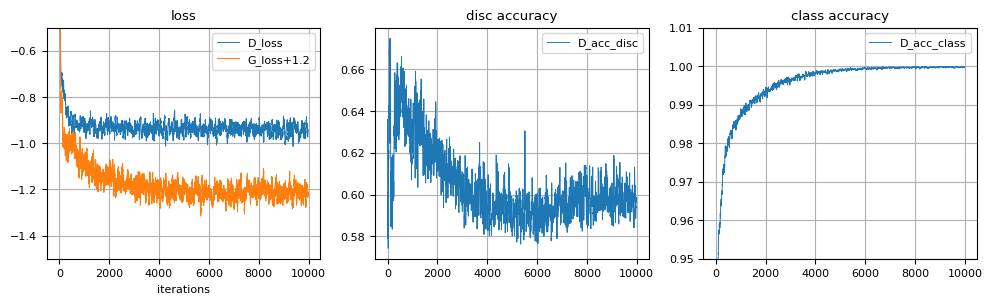

In [ ]:
lw = 0.7
plt.figure(figsize=(10,9))
plt.subplot(321)
plt.title("mi loss")
plt.plot(ma(D_mi),label="D_mi",linewidth=lw)
plt.plot(ma(G_mi)+2,label="G_mi+2",linewidth=lw)
plt.ylim(-1.7,-0.5)
plt.grid()
plt.legend()

plt.subplot(322)
plt.title("binary-ce loss")
plt.plot(ma(D_real_ce+D_fake_ce)-0.5 ,label="D_ce-0.5",linewidth=lw)
plt.plot(ma(G_ce), label="G_ce",linewidth=lw)
plt.ylim(0.7,1.2)
plt.grid()
plt.legend()

plt.subplot(323)
plt.plot(ma(D_mi_fake)+3, label="D_fake_mi+3",linewidth=lw)
plt.plot(ma(D_mi_real), label="D_real_mi",linewidth=lw)
plt.ylim(-0.5,0.5)
plt.grid()
plt.legend()

plt.subplot(324)
#plt.title("cross enctropy loss")
plt.plot(ma(D_real_ce) ,label="D_real_ce",linewidth=lw)
plt.plot(ma(D_fake_ce), label="D_fake_ce",linewidth=lw)
plt.ylim(0.5,1)
plt.grid()
plt.legend()

plt.subplot(325)
plt.title("disc acc")
plt.xlabel("iterations")
plt.plot(ma(D_acc_real,n=50),label="D_real",linewidth=lw)
plt.plot(ma(D_acc_fake,n=50),label="D_fake",linewidth=lw)
#plt.ylim(-3.5,-2.5)
plt.grid()
plt.legend()

plt.subplot(326)
plt.title("class acc")
plt.plot(ma(D_acc_class_real) ,label="D_real",linewidth=lw)
plt.plot(ma(D_acc_class_fake), label="D_fake",linewidth=lw)
plt.ylim(0.97,1.005)
plt.grid()
plt.legend()
plt.show()

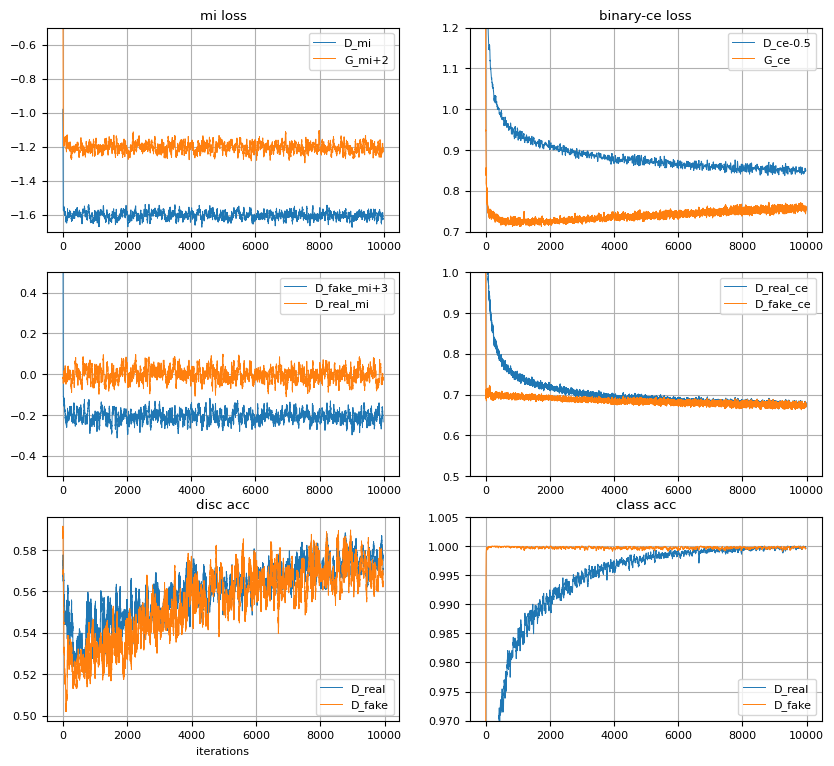

In [ ]:
# (Google Drive 연결 셀 제거 — 저장 경로는 /content/models/PT/ 로 바꿨다)
# # gdriver mount to load saved model
save_path='/content/models/PT/'


In [ ]:
#torch.save(info_generator, save_path+'infoGAN_generator.pt')

In [ ]:
#!cp -r ./infoGANgenerator/ /gdrive/MyDrive/models/infoGANgenerator/

- Model load

In [ ]:
info_generator = torch.load(save_path+'infoGAN_generator.pt')

### latent code1,2 특징 확인

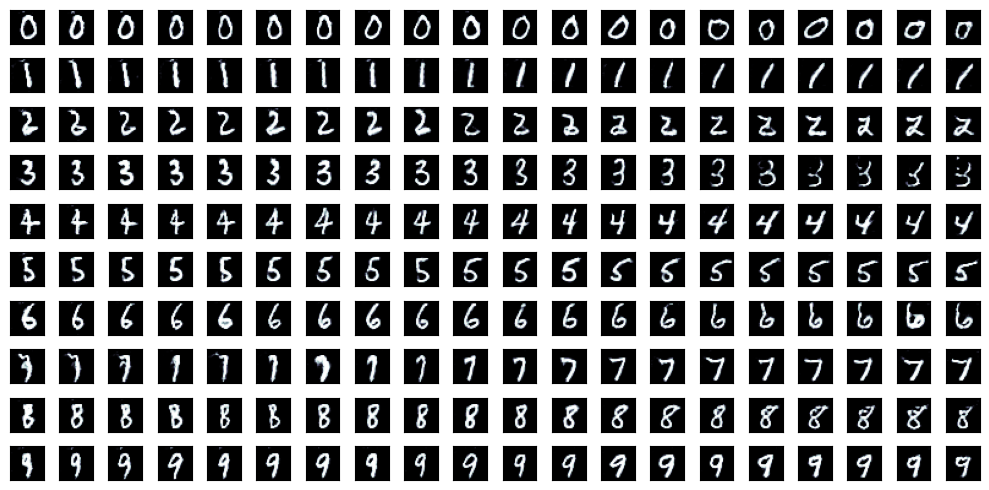

In [ ]:
r, c = 10, 20
code1_l = -1.5 #code1_min
code1_h = 1.5  #code1_max
code2_l = -0   #code2_min
code2_h = 0    #code2_max

fig = plt.figure(figsize=(10,5))
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
for i in range(r):
    noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
    # class label (20,10)
    noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)
    noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)# code1 (20, 1)
    noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)# code2 (20, 1)
    # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)])
    gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(c): # 20개 이미지 출력
        ax = fig.add_subplot(r, c, i * c + j + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

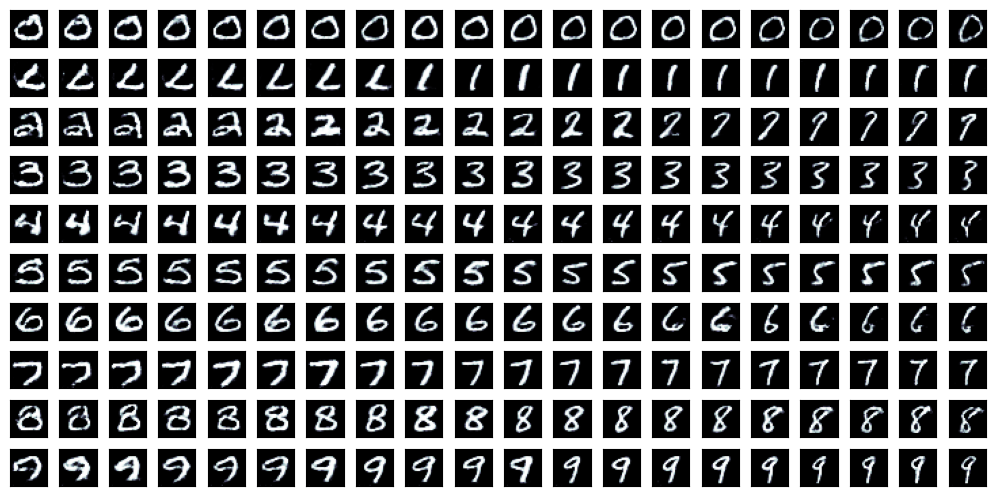

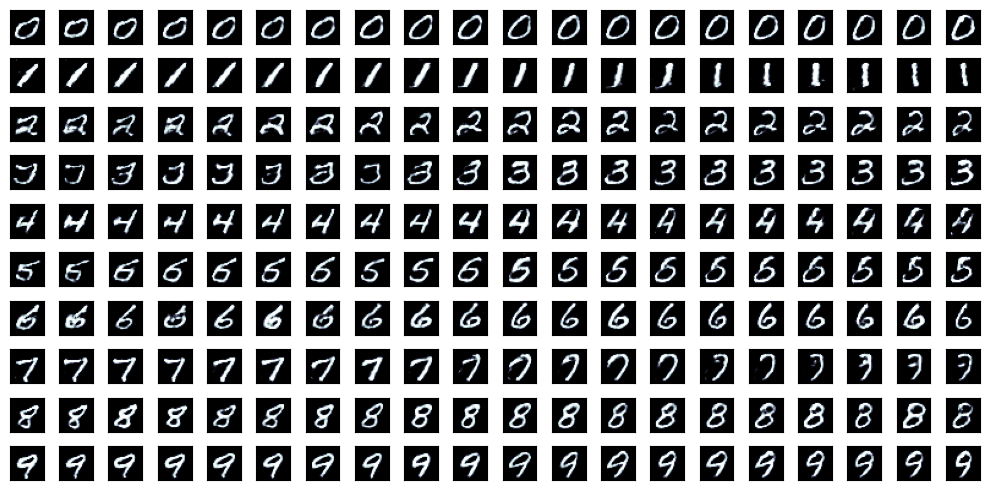

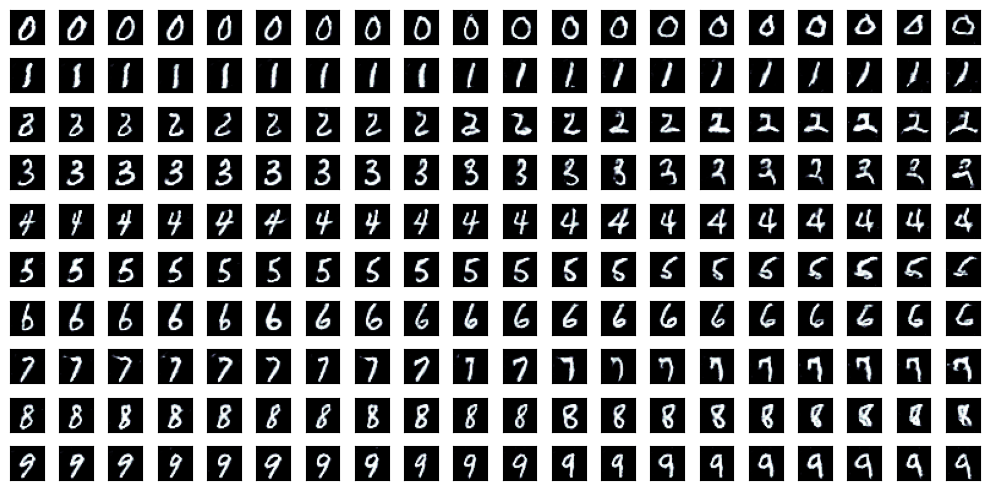

In [ ]:
r, c = 10, 20
code1_l = -0    #code1_min
code1_h = 0     #code1_max
code2_l = -1.5  #code2_min
code2_h = 1.5   #code2_max

fig = plt.figure(figsize=(10,5))
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
for i in range(r):
    noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
    # class label (20,10)
    noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)
    noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)# code1 (20, 1)
    noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)# code2 (20, 1)
    # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)])
    gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(c): # 20개 이미지 출력
        ax = fig.add_subplot(r, c, i * c + j + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

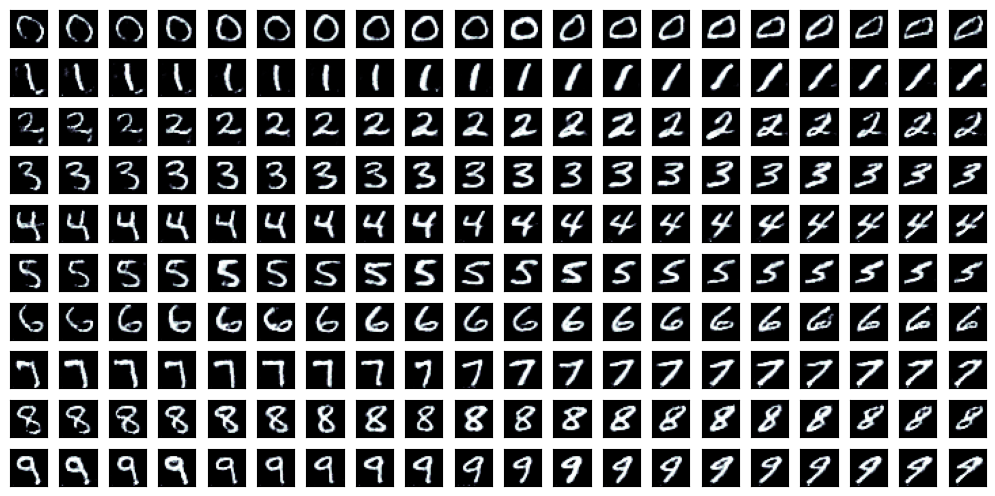

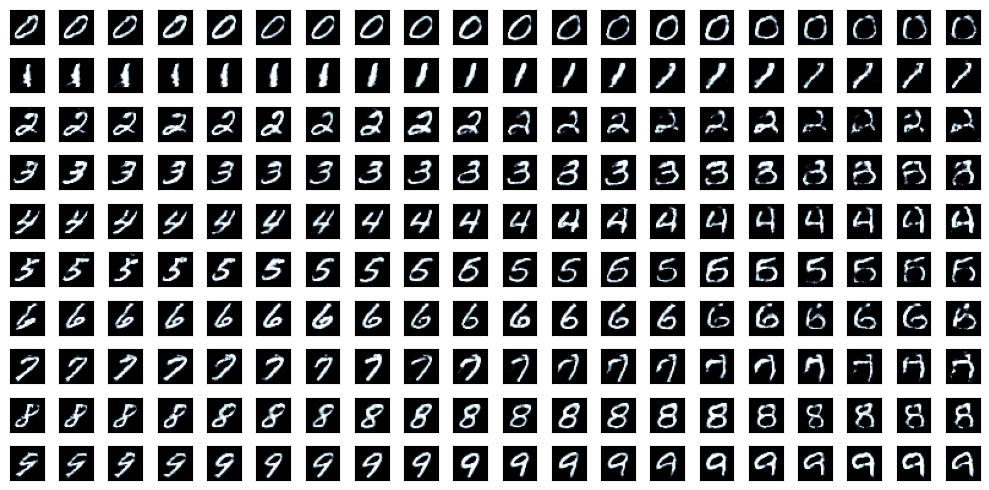

Min_Max Range:0.5


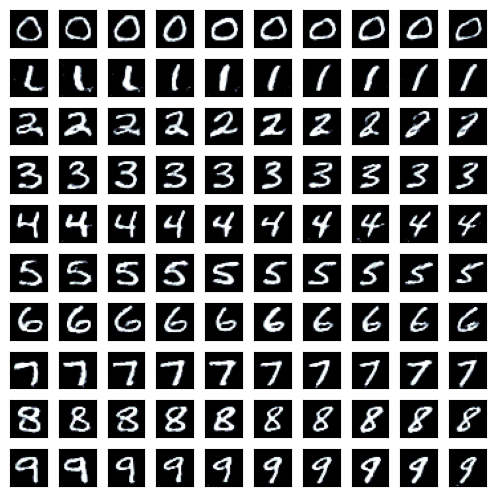

Min_Max Range:0.7


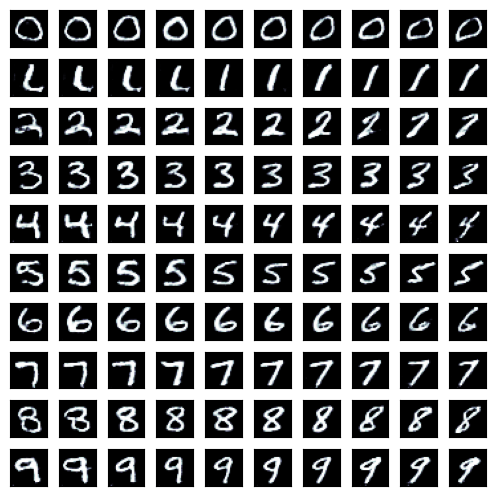

Min_Max Range:1.0


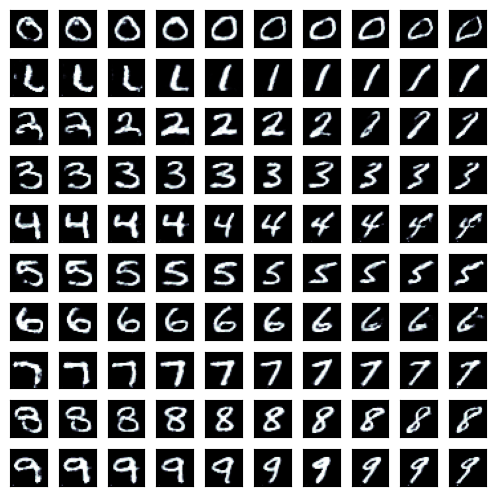

Min_Max Range:1.5


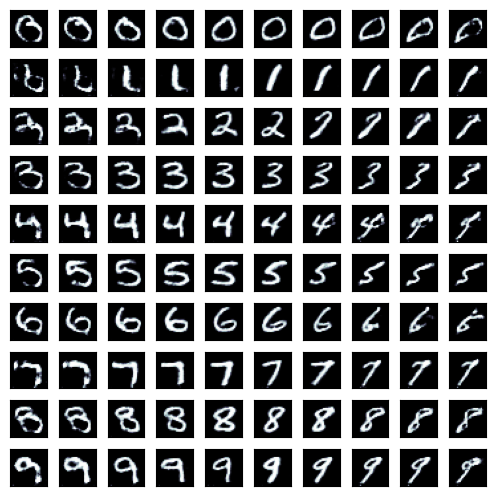

In [ ]:
r, c = 10, 10
c_range = [0.5,0.7,1.0,1.5]

for r_idx in range(len(c_range)):
    code1_l = code2_l = - c_range[r_idx]  #code12_min
    code1_h = code2_h = c_range[r_idx]   #code12_max
    fig = plt.figure(figsize=(5,5))
    plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
    print(f"Min_Max Range:{c_range[r_idx]}")
    for i in range(r):
        noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
        # class label (20,10)
        noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)
        noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)# code1 (20, 1)
        noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)# code2 (20, 1)
        # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)])
        gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
        gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
        for j in range(c): # 20개 이미지 출력
            ax = fig.add_subplot(r, c, i * c + j + 1)
            ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.show()

# 추가로 해볼만한 작업

MI 정보 시각화 (code1, code2 복원 정확도 heatmap)

λ_MI 튜닝에 따른 FID/IS 변화 분석